### Introduction to Deep Learning - CS672 - 71942 - Fall 2025 - Project 2

In [1]:
!pip install -q "meteostat==1.6.8" "pandas==2.2.2"
print("✅ Installed.")

✅ Installed.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from datetime import datetime
from meteostat import Point, Daily

import seaborn as sns
from sklearn.preprocessing import StandardScaler

import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Input, Dropout

from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import SGD, Adam, RMSprop

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)

pd.set_option("display.max_columns", 60)
print("TensorFlow:", tf.__version__)
print("pandas    :", pd.__version__)   # should be 2.2.2

TensorFlow: 2.20.0
pandas    : 2.2.2


## Data Load

In [2]:
# --- NYC Yellow Taxi data: January 2020 ---
TAXI_URL = "https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_2020-01.parquet"

print("Loading taxi data from:", TAXI_URL)
taxi_df = pd.read_parquet(TAXI_URL)
print("Taxi shape:", taxi_df.shape)
display(taxi_df.head())

# --- NYC Weather data via Meteostat API (Wall Street) ---
nyc_point = Point(40.7060, -74.0086)

start = datetime(2020, 1, 1)
end   = datetime(2020, 1, 31)

weather_jan = Daily(nyc_point, start=start, end=end).fetch()
weather_df = weather_jan.reset_index().rename(columns={"time": "date"})

print("Weather (Jan 2020) shape:", weather_df.shape)
display(weather_df.head())

Loading taxi data from: https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_2020-01.parquet
Taxi shape: (6405008, 19)


,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee
0,1,2020-01-01 00:28:15,2020-01-01 00:33:03,1.0,1.2,1.0,N,238,239,1,6.0,3.0,0.5,1.47,0.0,0.3,11.27,2.5,None
1,1,2020-01-01 00:35:39,2020-01-01 00:43:04,1.0,1.2,1.0,N,239,238,1,7.0,3.0,0.5,1.50,0.0,0.3,12.30,2.5,None
2,1,2020-01-01 00:47:41,2020-01-01 00:53:52,1.0,0.6,1.0,N,238,238,1,6.0,3.0,0.5,1.00,0.0,0.3,10.80,2.5,None
3,1,2020-01-01 00:55:23,2020-01-01 01:00:14,1.0,0.8,1.0,N,238,151,1,5.5,0.5,0.5,1.36,0.0,0.3,8.16,0.0,None
4,2,2020-01-01 00:01:58,2020-01-01 00:04:16,1.0,0.0,1.0,N,193,193,2,3.5,0.5,0.5,0.00,0.0,0.3,4.80,0.0,None


Weather (Jan 2020) shape: (31, 11)


,date,tavg,tmin,tmax,prcp,snow,wdir,wspd,wpgt,pres,tsun
0,2020-01-01,3.6,1.7,5.0,0.0,0.0,272.0,17.3,NaN,1008.2,NaN
1,2020-01-02,4.7,0.6,8.9,0.0,0.0,218.0,12.4,NaN,1013.9,NaN
2,2020-01-03,7.6,6.7,8.3,3.6,0.0,257.0,8.4,NaN,1010.2,NaN
3,2020-01-04,8.2,6.7,9.4,6.1,0.0,13.0,5.7,NaN,1003.7,NaN
4,2020-01-05,4.6,2.8,7.2,0.0,0.0,311.0,8.2,NaN,1010.1,NaN


### Data Cleaning & Feature Engineering


In [3]:
df = taxi_df.copy()

# Ensure datetime
df["tpep_pickup_datetime"] = pd.to_datetime(df["tpep_pickup_datetime"])
df["tpep_dropoff_datetime"] = pd.to_datetime(df["tpep_dropoff_datetime"])

# Trip duration in minutes (target)
df["trip_duration_min"] = (
    df["tpep_dropoff_datetime"] - df["tpep_pickup_datetime"]
).dt.total_seconds() / 60.0

# Basic trip filters
df = df[
    (df["trip_duration_min"] > 1) &
    (df["trip_duration_min"] <= 180) &
    (df["trip_distance"] > 0) &
    (df["trip_distance"] <= 50)
].copy()

df = df.dropna(subset=["trip_distance", "trip_duration_min"])

# Time features
df["pickup_hour"] = df["tpep_pickup_datetime"].dt.hour
df["pickup_weekday"] = df["tpep_pickup_datetime"].dt.weekday
df["is_weekend"] = df["pickup_weekday"].isin([5, 6]).astype(int)
df["is_rush_hour"] = df["pickup_hour"].isin([7, 8, 9, 16, 17, 18, 19]).astype(int)

# For merging with weather
df["pickup_date"] = df["tpep_pickup_datetime"].dt.normalize()

print("Cleaned taxi shape:", df.shape)
display(df.head())

Cleaned taxi shape: (6294171, 25)


,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee,trip_duration_min,pickup_hour,pickup_weekday,is_weekend,is_rush_hour,pickup_date
0,1,2020-01-01 00:28:15,2020-01-01 00:33:03,1.0,1.2,1.0,N,238,239,1,6.0,3.0,0.5,1.47,0.0,0.3,11.27,2.5,None,4.800000,0,2,0,0,2020-01-01
1,1,2020-01-01 00:35:39,2020-01-01 00:43:04,1.0,1.2,1.0,N,239,238,1,7.0,3.0,0.5,1.50,0.0,0.3,12.30,2.5,None,7.416667,0,2,0,0,2020-01-01
2,1,2020-01-01 00:47:41,2020-01-01 00:53:52,1.0,0.6,1.0,N,238,238,1,6.0,3.0,0.5,1.00,0.0,0.3,10.80,2.5,None,6.183333,0,2,0,0,2020-01-01
3,1,2020-01-01 00:55:23,2020-01-01 01:00:14,1.0,0.8,1.0,N,238,151,1,5.5,0.5,0.5,1.36,0.0,0.3,8.16,0.0,None,4.850000,0,2,0,0,2020-01-01
9,1,2020-01-01 00:29:01,2020-01-01 00:40:28,2.0,0.7,1.0,N,246,48,1,8.0,3.0,0.5,2.35,0.0,0.3,14.15,2.5,None,11.450000,0,2,0,0,2020-01-01


##Merging Taxi Trip Data with Weather Information

In [4]:
w = weather_df.copy()
w["date"] = pd.to_datetime(w["date"])
w = w.sort_values("date").copy()
w = w.interpolate(method="linear", limit_direction="both").copy()

merged_df = df.merge(
    w,
    left_on="pickup_date",
    right_on="date",
    how="left"
).copy()

merged_df.drop(columns=["date"], inplace=True, errors="ignore")

print("Merged_df shape:", merged_df.shape)
display(merged_df.head())

Merged_df shape: (6294171, 35)


,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee,trip_duration_min,pickup_hour,pickup_weekday,is_weekend,is_rush_hour,pickup_date,tavg,tmin,tmax,prcp,snow,wdir,wspd,wpgt,pres,tsun
0,1,2020-01-01 00:28:15,2020-01-01 00:33:03,1.0,1.2,1.0,N,238,239,1,6.0,3.0,0.5,1.47,0.0,0.3,11.27,2.5,None,4.800000,0,2,0,0,2020-01-01,3.6,1.7,5.0,0.0,0.0,272.0,17.3,NaN,1008.2,NaN
1,1,2020-01-01 00:35:39,2020-01-01 00:43:04,1.0,1.2,1.0,N,239,238,1,7.0,3.0,0.5,1.50,0.0,0.3,12.30,2.5,None,7.416667,0,2,0,0,2020-01-01,3.6,1.7,5.0,0.0,0.0,272.0,17.3,NaN,1008.2,NaN
2,1,2020-01-01 00:47:41,2020-01-01 00:53:52,1.0,0.6,1.0,N,238,238,1,6.0,3.0,0.5,1.00,0.0,0.3,10.80,2.5,None,6.183333,0,2,0,0,2020-01-01,3.6,1.7,5.0,0.0,0.0,272.0,17.3,NaN,1008.2,NaN
3,1,2020-01-01 00:55:23,2020-01-01 01:00:14,1.0,0.8,1.0,N,238,151,1,5.5,0.5,0.5,1.36,0.0,0.3,8.16,0.0,None,4.850000,0,2,0,0,2020-01-01,3.6,1.7,5.0,0.0,0.0,272.0,17.3,NaN,1008.2,NaN
4,1,2020-01-01 00:29:01,2020-01-01 00:40:28,2.0,0.7,1.0,N,246,48,1,8.0,3.0,0.5,2.35,0.0,0.3,14.15,2.5,None,11.450000,0,2,0,0,2020-01-01,3.6,1.7,5.0,0.0,0.0,272.0,17.3,NaN,1008.2,NaN


##Feature Engineering – Creating Derived & Weather-Enhanced Features

In [5]:
# Features known (or estimable) at PICKUP time
feature_cols = [
    "passenger_count",
    "trip_distance",      # metered distance — dominant legit driver of duration
    "pickup_hour",
    "pickup_weekday",
    "is_weekend",
    "is_rush_hour",
]

# Add weather features if present
weather_feature_candidates = ["tavg", "tmin", "tmax", "prcp", "snow",
                              "wdir", "wspd", "pres", "tsun"]
for col in weather_feature_candidates:
    if col in merged_df.columns:
        feature_cols.append(col)

print("Using features (leakage-free):", feature_cols)

Using features (leakage-free): ['passenger_count', 'trip_distance', 'pickup_hour', 'pickup_weekday', 'is_weekend', 'is_rush_hour', 'tavg', 'tmin', 'tmax', 'prcp', 'snow', 'wdir', 'wspd', 'pres', 'tsun']


##Heatmap

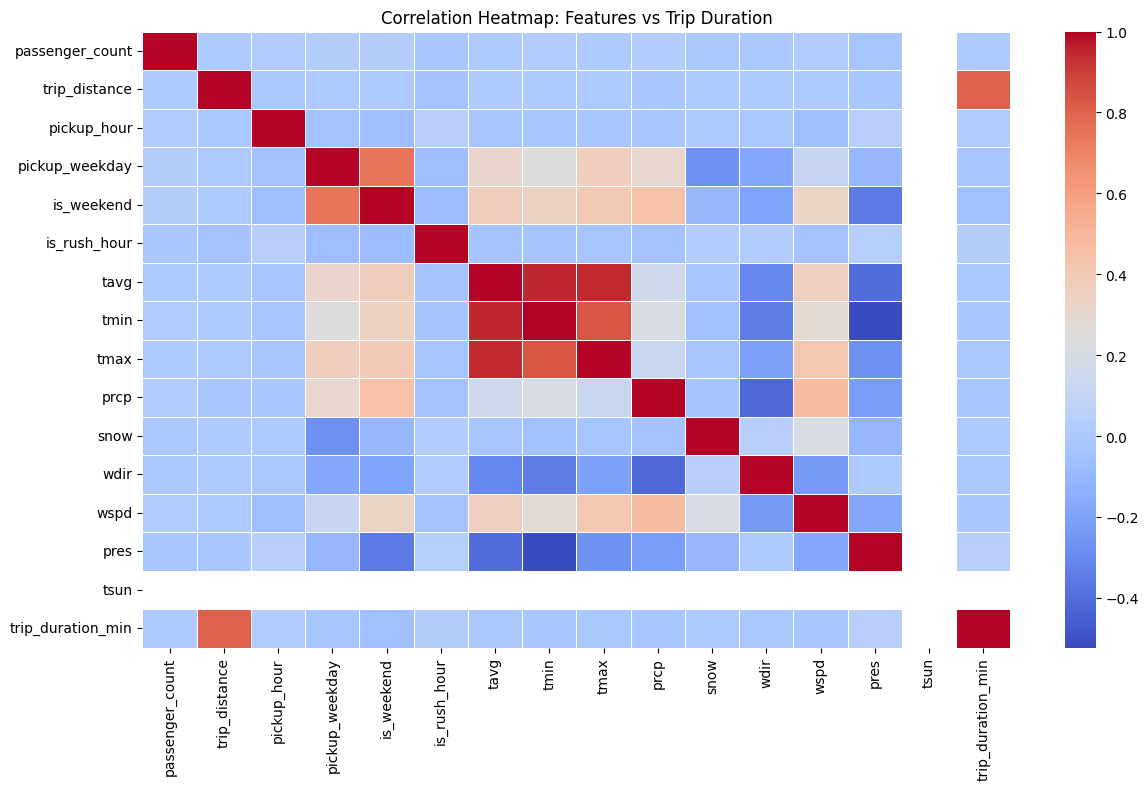

In [6]:
plt.figure(figsize=(14,8))
corr_matrix = merged_df[feature_cols + ["trip_duration_min"]].corr()
sns.heatmap(corr_matrix, annot=False, cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Heatmap: Features vs Trip Duration")
plt.show()

##Trip Duration on Rainy vs Clear Days

Columns now: ['VendorID', 'tpep_pickup_datetime', 'tpep_dropoff_datetime', 'passenger_count', 'trip_distance', 'RatecodeID', 'store_and_fwd_flag', 'PULocationID', 'DOLocationID', 'payment_type', 'fare_amount', 'extra', 'mta_tax', 'tip_amount', 'tolls_amount', 'improvement_surcharge', 'total_amount', 'congestion_surcharge', 'airport_fee', 'trip_duration_min', 'pickup_hour', 'pickup_weekday', 'is_weekend', 'is_rush_hour', 'pickup_date', 'tavg', 'tmin', 'tmax', 'prcp', 'snow', 'wdir', 'wspd', 'wpgt', 'pres', 'tsun', 'rainy']
   prcp  rainy
0   0.0      0
1   0.0      0
2   0.0      0
3   0.0      0
4   0.0      0


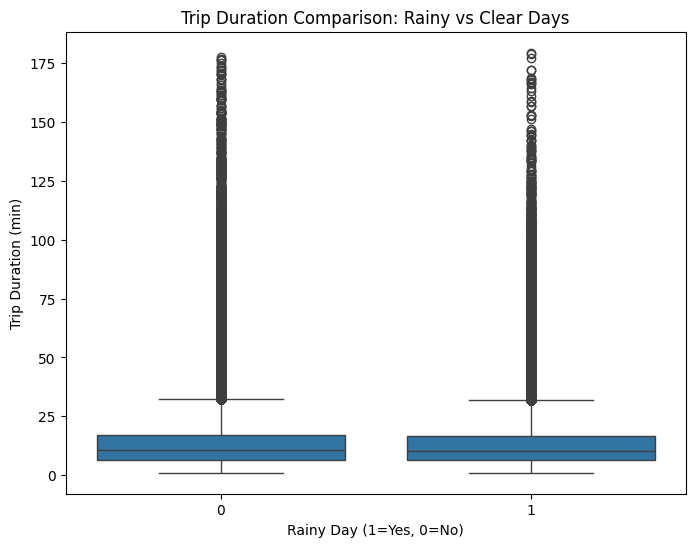

In [7]:
# Ensure precipitation (prcp) exists and treat missing values
if "prcp" in merged_df.columns:
    merged_df["prcp"] = merged_df["prcp"].fillna(0)
    merged_df["rainy"] = (merged_df["prcp"] > 0).astype(int)
else:
    print("⚠️ 'prcp' column not found — cannot create rainy flag.")

print("Columns now:", merged_df.columns.tolist())
print(merged_df[["prcp", "rainy"]].head())

plt.figure(figsize=(8,6))
sns.boxplot(x="rainy", y="trip_duration_min", data=merged_df)
plt.xlabel("Rainy Day (1=Yes, 0=No)")
plt.ylabel("Trip Duration (min)")
plt.title("Trip Duration Comparison: Rainy vs Clear Days")
plt.show()

##Average Trip Duration by Temperature Zones

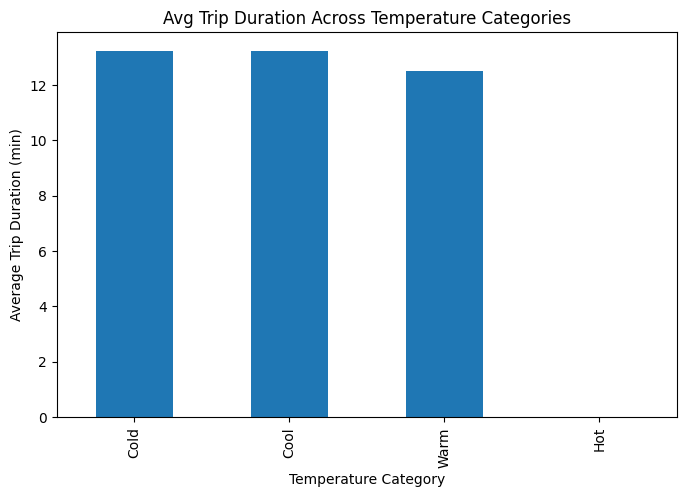

In [8]:
merged_df["temp_bucket"] = pd.cut(merged_df["tavg"], bins=[-5,5,15,25,35],
                                  labels=["Cold","Cool","Warm","Hot"])

plt.figure(figsize=(8,5))
merged_df.groupby("temp_bucket")["trip_duration_min"].mean().plot(kind="bar")
plt.title("Avg Trip Duration Across Temperature Categories")
plt.ylabel("Average Trip Duration (min)")
plt.xlabel("Temperature Category")
plt.show()

##Weather Condition Effect on Trip Duration

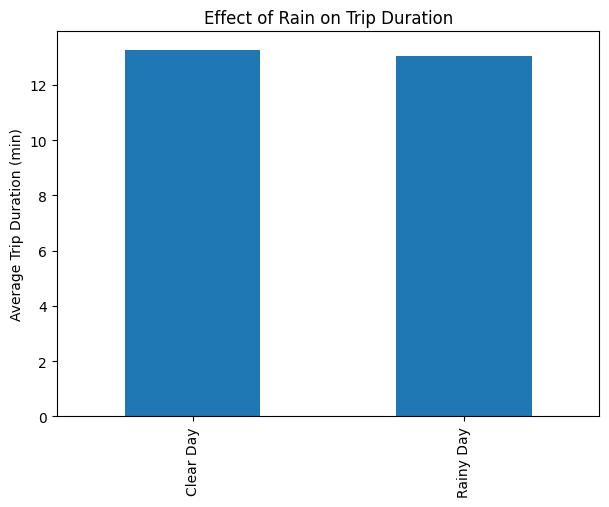

In [9]:
weather_effect = merged_df.groupby("rainy")["trip_duration_min"].mean()
weather_effect.index = ["Clear Day", "Rainy Day"]

plt.figure(figsize=(7,5))
weather_effect.plot(kind="bar")
plt.title("Effect of Rain on Trip Duration")
plt.ylabel("Average Trip Duration (min)")
plt.show()

##Relationship Exploration

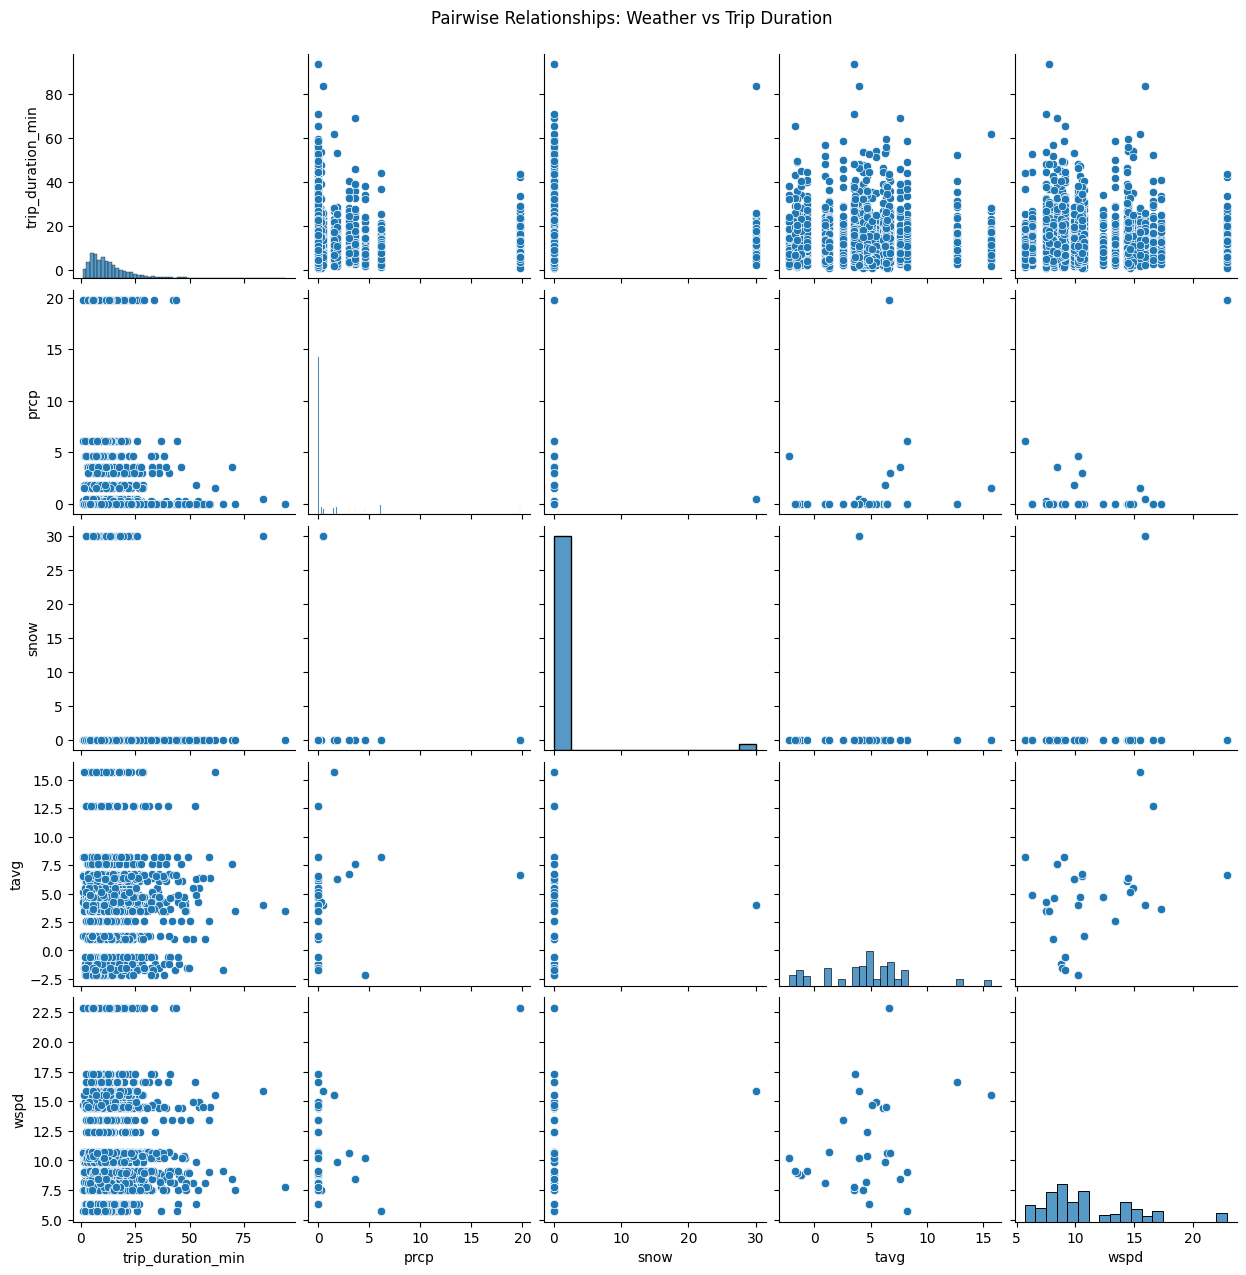

In [10]:
sns.pairplot(merged_df[["trip_duration_min", "prcp", "snow", "tavg", "wspd"]].sample(2000))
plt.suptitle("Pairwise Relationships: Weather vs Trip Duration", y=1.02)
plt.show()

In [11]:
# Sample a subset for faster training (lower frac if Colab is slow)
sample_frac = 0.05   # ~5% of trips; set 0.02 for a quicker run
merged_df_sampled = merged_df.sample(
    frac=sample_frac, random_state=RANDOM_SEED
).reset_index(drop=True)

print("After sampling:", merged_df_sampled.shape)

After sampling: (314709, 37)


In [12]:
# Sort by time for time-aware split
merged_df_sorted = merged_df_sampled.sort_values("tpep_pickup_datetime").reset_index(drop=True)

X_sorted = merged_df_sorted[feature_cols].copy()
y_sorted = merged_df_sorted["trip_duration_min"].values

# Keep only numeric columns
X_sorted = X_sorted.select_dtypes(include=[np.number]).copy()

# Drop columns that are fully NaN
X_sorted = X_sorted.dropna(axis=1, how="all").copy()

# Fill remaining NaNs with column medians
for col in X_sorted.columns:
    if X_sorted[col].isna().any():
        X_sorted[col] = X_sorted[col].fillna(X_sorted[col].median())

print("X_sorted shape:", X_sorted.shape, "y_sorted shape:", y_sorted.shape)
print("Final features used:", list(X_sorted.columns))

# Train/validation split: 80/20 by time (no shuffling — respects time order)
n = len(X_sorted)
train_size = int(0.8 * n)

X_train = X_sorted.iloc[:train_size].values
X_val   = X_sorted.iloc[train_size:].values
y_train = y_sorted[:train_size]
y_val   = y_sorted[train_size:]

print("Train size:", X_train.shape[0], "Val size:", X_val.shape[0])

# Final NaN/inf guard
X_train = np.nan_to_num(X_train, nan=0.0, posinf=0.0, neginf=0.0)
X_val   = np.nan_to_num(X_val,   nan=0.0, posinf=0.0, neginf=0.0)

# Scale (fit on train only)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled   = scaler.transform(X_val)

input_dim = X_train_scaled.shape[1]
print("Input dim:", input_dim)

X_sorted shape: (314709, 14) y_sorted shape: (314709,)
Final features used: ['passenger_count', 'trip_distance', 'pickup_hour', 'pickup_weekday', 'is_weekend', 'is_rush_hour', 'tavg', 'tmin', 'tmax', 'prcp', 'snow', 'wdir', 'wspd', 'pres']
Train size: 251767 Val size: 62942
Input dim: 14


##Model Building: Linear Regression, MLP, and DNN

In [13]:
print("TF version:", tf.__version__)
print("GPUs:", tf.config.list_physical_devices('GPU'))

if tf.config.list_physical_devices('GPU'):
    print("✅ GPU is visible to TensorFlow.")
else:
    print("❌ No GPU visible. In Colab: Runtime → Change runtime type → GPU")

TF version: 2.20.0
GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
✅ GPU is visible to TensorFlow.


In [14]:
# Three architectures (per project spec):
#   1) Linear Regression — no hidden layers
#   2) MLP — two hidden layers
#   3) DNN — deeper + dropout regularization

def build_linear_regression_model(input_dim):
    model = Sequential([
        Input(shape=(input_dim,)),
        Dense(1)                      # no hidden layers → linear regression
    ])
    return model

def build_mlp_model(input_dim):
    model = Sequential([
        Input(shape=(input_dim,)),
        Dense(64, activation="relu"),
        Dense(32, activation="relu"),
        Dense(1)
    ])
    return model

def build_dnn_model(input_dim):
    model = Sequential([
        Input(shape=(input_dim,)),
        Dense(128, activation="relu"),
        Dropout(0.3),
        Dense(64, activation="relu"),
        Dropout(0.2),
        Dense(32, activation="relu"),
        Dense(1)
    ])
    return model

print("✓ Model builders defined: Linear, MLP, DNN")

✓ Model builders defined: Linear, MLP, DNN


In [15]:
def compile_and_train(model, optimizer, loss_fn,
                      X_train, y_train, X_val, y_val,
                      epochs=100, batch_size=32, verbose=0,
                      callbacks=None):
    """Compile a Keras model, train it, and return history."""
    model.compile(optimizer=optimizer, loss=loss_fn, metrics=["mae"])
    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=epochs,
        batch_size=batch_size,
        verbose=verbose,
        callbacks=callbacks or []
    )
    return history

# EarlyStopping to avoid wasting epochs
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

experiments = []

model_builders = {
    "Linear": build_linear_regression_model,
    "MLP":    build_mlp_model,
    "DNN":    build_dnn_model
}

optimizers_config = [
    ("Adam",    Adam),
    ("RMSprop", RMSprop)
]

learning_rates = [1e-3]
EPOCHS = 40
BATCH_SIZE = 32
LOSS_FN = "mse"          # project requires MSE; MAE tracked as metric

gpus = tf.config.list_physical_devices('GPU')
device_name = "/GPU:0" if gpus else "/CPU:0"
print("✅ Using GPU:" if gpus else "⚠️ No GPU, using CPU:", device_name)

with tf.device(device_name):
    for model_name, builder in model_builders.items():
        for opt_name, opt_class in optimizers_config:
            for lr in learning_rates:
                print(f"\n=== Training {model_name} with {opt_name}, lr={lr} ===")
                model = builder(input_dim)
                optimizer = opt_class(learning_rate=lr)

                history = compile_and_train(
                    model, optimizer, LOSS_FN,
                    X_train_scaled, y_train,
                    X_val_scaled,   y_val,
                    epochs=EPOCHS, batch_size=BATCH_SIZE,
                    verbose=1, callbacks=[early_stop]
                )

                experiments.append({
                    "model": model_name,
                    "optimizer": opt_name,
                    "lr": lr,
                    "final_train_loss": history.history["loss"][-1],
                    "final_val_loss":   history.history["val_loss"][-1],
                    "final_train_mae":  history.history["mae"][-1],
                    "final_val_mae":    history.history["val_mae"][-1],
                    "history": history,
                    "trained_model": model
                })

print("\nTotal experiments:", len(experiments))

✅ Using GPU: /GPU:0

=== Training Linear with Adam, lr=0.001 ===
Epoch 1/40
7868/7868 ━━━━━━━━━━━━━━━━━━━━ 25s 3ms/step - loss: 159.0646 - mae: 9.5047 - val_loss: 91.0451 - val_mae: 6.9067
Epoch 2/40
7868/7868 ━━━━━━━━━━━━━━━━━━━━ 24s 3ms/step - loss: 46.5414 - mae: 4.5918 - val_loss: 38.9026 - val_mae: 4.2514
Epoch 3/40
7868/7868 ━━━━━━━━━━━━━━━━━━━━ 24s 3ms/step - loss: 33.3952 - mae: 4.0420 - val_loss: 37.5849 - val_mae: 4.2299
Epoch 4/40
7868/7868 ━━━━━━━━━━━━━━━━━━━━ 23s 3ms/step - loss: 33.3595 - mae: 4.0495 - val_loss: 37.5850 - val_mae: 4.2291
Epoch 5/40
7868/7868 ━━━━━━━━━━━━━━━━━━━━ 23s 3ms/step - loss: 33.3586 - mae: 4.0492 - val_loss: 37.5851 - val_mae: 4.2290
Epoch 6/40
7868/7868 ━━━━━━━━━━━━━━━━━━━━ 42s 3ms/step - loss: 33.3584 - mae: 4.0491 - val_loss: 37.5848 - val_mae: 4.2290
Epoch 7/40
7868/7868 ━━━━━━━━━━━━━━━━━━━━ 26s 3ms/step - loss: 33.3583 - mae: 4.0491 - val_loss: 37.5845 - val_mae: 4.2290
Epoch 8/40
7868/7868 ━━━━━━━━━━━━━━━━━━━━ 38s 3ms/step - loss: 33.3584 - 

In [16]:
results_df = pd.DataFrame([
    {
        "Model": exp["model"],
        "Optimizer": exp["optimizer"],
        "LR": exp["lr"],
        "Train_MSE": exp["final_train_loss"],
        "Val_MSE": exp["final_val_loss"],
        "Train_MAE": exp["final_train_mae"],
        "Val_MAE": exp["final_val_mae"],
    }
    for exp in experiments
])

results_df = results_df.sort_values("Val_MAE").reset_index(drop=True)
display(results_df)

,Model,Optimizer,LR,Train_MSE,Val_MSE,Train_MAE,Val_MAE
0,MLP,Adam,0.001,20.567980,25.489550,2.943973,3.305843
1,DNN,Adam,0.001,22.902672,27.377352,3.115577,3.323213
2,DNN,RMSprop,0.001,22.999723,28.144030,3.149353,3.456602
3,MLP,RMSprop,0.001,21.390610,28.877979,3.008492,3.553445
4,Linear,RMSprop,0.001,33.364395,37.478619,4.042592,4.224400
5,Linear,Adam,0.001,33.358227,37.582390,4.049041,4.228967


In [17]:
import os

SAVE_DIR = "content/saved_models"
os.makedirs(SAVE_DIR, exist_ok=True)

best_by_model = {}
for exp in experiments:
    name = exp["model"]
    if name not in best_by_model or exp["final_val_mae"] < best_by_model[name]["final_val_mae"]:
        best_by_model[name] = exp

print("Best config per model type:")
for name, exp in best_by_model.items():
    print(f"  {name}: optimizer={exp['optimizer']}, lr={exp['lr']}, Val_MAE={exp['final_val_mae']:.4f}")

for name, exp in best_by_model.items():
    filename = f"{name}_{exp['optimizer']}_lr{exp['lr']:.0e}.keras"
    filepath = os.path.join(SAVE_DIR, filename)
    exp["trained_model"].save(filepath)
    print(f"✅ Saved {name} → {filepath}")

Best config per model type:
  Linear: optimizer=RMSprop, lr=0.001, Val_MAE=4.2244
  MLP: optimizer=Adam, lr=0.001, Val_MAE=3.3058
  DNN: optimizer=Adam, lr=0.001, Val_MAE=3.3232
✅ Saved Linear → content/saved_models/Linear_RMSprop_lr1e-03.keras
✅ Saved MLP → content/saved_models/MLP_Adam_lr1e-03.keras
✅ Saved DNN → content/saved_models/DNN_Adam_lr1e-03.keras


Best model configuration:
  Model:     MLP
  Optimizer: Adam
  LR:        0.001
  Val_MAE:   3.3058 minutes
  Val_MSE:   25.4895


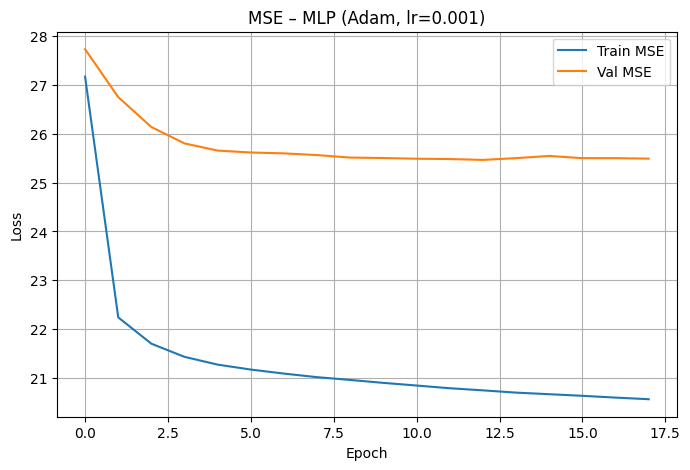

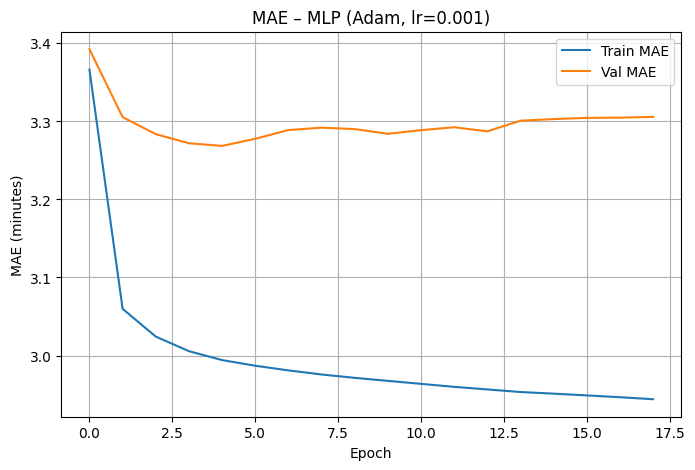

In [18]:
best_exp = min(experiments, key=lambda e: e["final_val_mae"])

print("Best model configuration:")
print("  Model:    ", best_exp["model"])
print("  Optimizer:", best_exp["optimizer"])
print("  LR:       ", best_exp["lr"])
print("  Val_MAE:  ", round(best_exp["final_val_mae"], 4), "minutes")
print("  Val_MSE:  ", round(best_exp["final_val_loss"], 4))

history = best_exp["history"]

plt.figure(figsize=(8,5))
plt.plot(history.history["loss"], label="Train MSE")
plt.plot(history.history["val_loss"], label="Val MSE")
plt.xlabel("Epoch"); plt.ylabel("Loss")
plt.title(f"MSE – {best_exp['model']} ({best_exp['optimizer']}, lr={best_exp['lr']})")
plt.legend(); plt.grid(True); plt.show()

plt.figure(figsize=(8,5))
plt.plot(history.history["mae"], label="Train MAE")
plt.plot(history.history["val_mae"], label="Val MAE")
plt.xlabel("Epoch"); plt.ylabel("MAE (minutes)")
plt.title(f"MAE – {best_exp['model']} ({best_exp['optimizer']}, lr={best_exp['lr']})")
plt.legend(); plt.grid(True); plt.show()